# Gene expression analysis

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [4]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"
mapping_dir = paste0(main, '07_atlas_mapping/')
out_dir = paste0(main, '09_gene_expression_analysis/')
plot_dir = paste0(main, '09_gene_expression_analysis/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)


source(paste0(main, "mapping_functions_extended.R"))

In [5]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

In [6]:
load_data(remove_doublets = TRUE, remove_stripped = TRUE)
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

In [7]:
sce
nrow(meta)

class: SingleCellExperiment 
dim: 29453 38320 
metadata(0):
assays(2): counts logcounts
rownames(29453): ENSMUSG00000051951 ENSMUSG00000089699 ...
  ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(38320): cell_1 cell_2 ... cell_45278 cell_45280
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

[1] 38320

In [8]:
meta$umap_1 = as.numeric(meta$umap_1)
meta$umap_2 = as.numeric(meta$umap_2)

In [9]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genenames = genenames[genenames$gene %in% rownames(sce)]
genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
genenames$gene_name[genenames$gene_name==''] = NA
genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
genenames = genenames[order(match(genenames$gene, rownames(sce)))]
rownames(sce) = genenames$gene_name

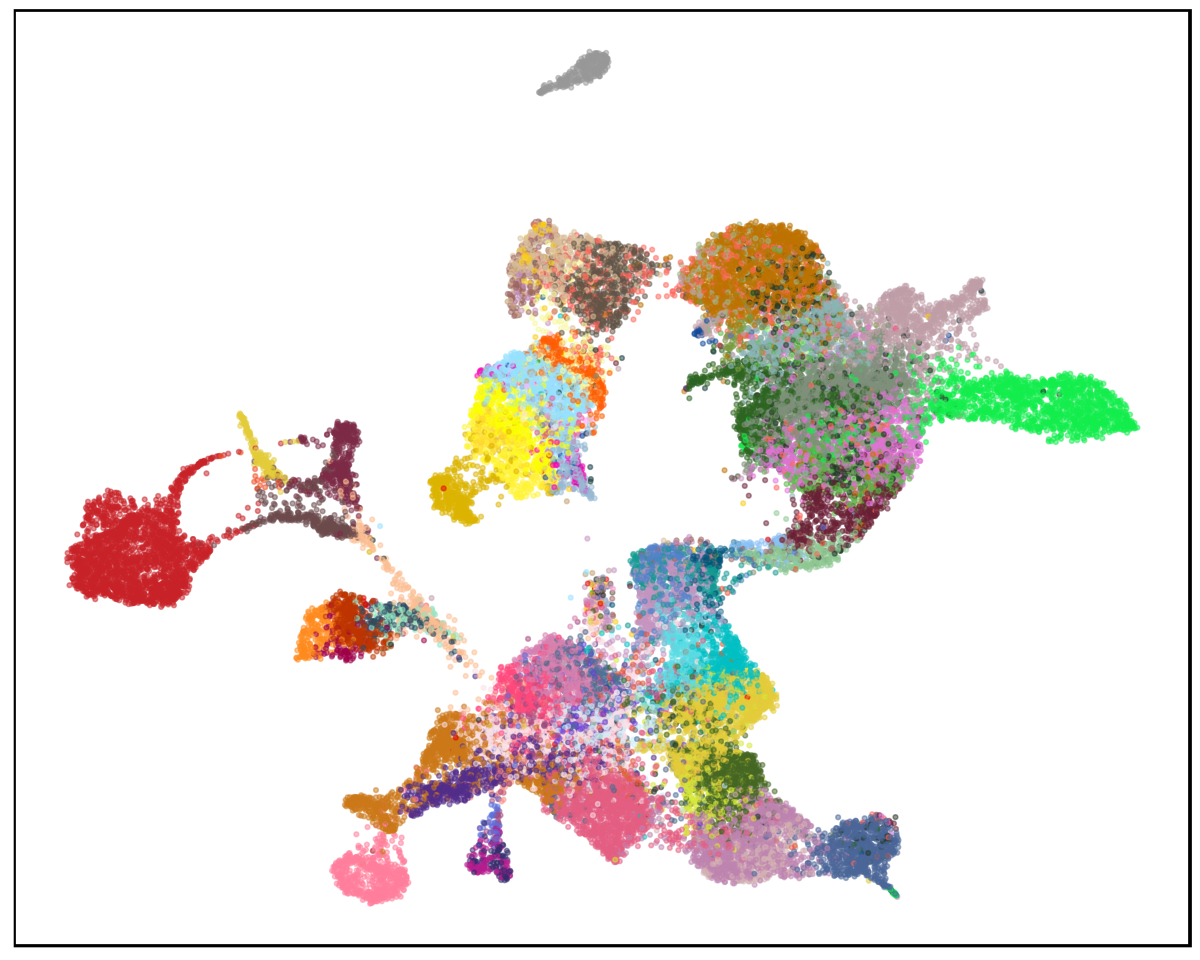

In [28]:
ggplot(meta, aes(umap_1, umap_2, col=celltype.mapped)) + 
        geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours_final,  name = "celltype") +
        umap_theme

In [11]:
sce

class: SingleCellExperiment 
dim: 29453 38320 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(38320): cell_1 cell_2 ... cell_45278 cell_45280
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

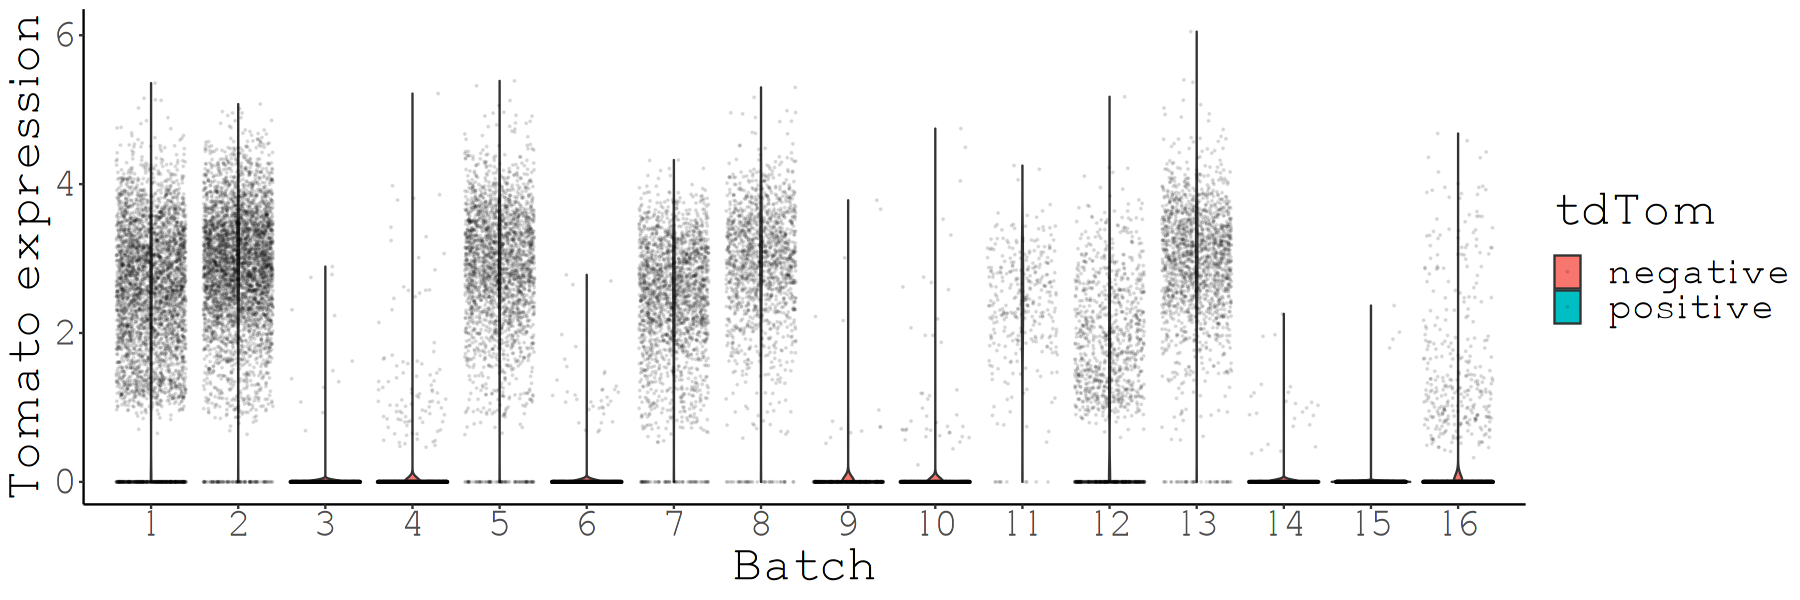

In [29]:
p6 = ggplot(meta, aes(as.factor(batch), as.vector(logcounts(sce[nrow(sce),])), group=batch, fill=tdTom)) + 
    geom_violin() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1, size = 0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')
options(repr.plot.width=15, repr.plot.height=5)
p6
options(repr.plot.width=15, repr.plot.height=8)

### Interrogation of specific gene sets

In [13]:
WT = meta[meta$tdTom=='negative',]
KO = meta[meta$tdTom!='negative',]

ct_nr = reshape2::dcast(as.data.frame(table(meta$celltype.mapped, meta$tdTom)), Var1 ~ Var2)
keep = ct_nr[ct_nr$negative>10 & ct_nr$positive>10,]$Var1

meta_seurat = meta[meta$celltype.mapped %in% keep,]
rownames(meta_seurat) = meta_seurat$cell
seurat = CreateSeuratObject(counts(sce[,meta_seurat$cell]), project = "SeuratProject", assay = "RNA",
  min.cells = 0, min.features = 0, meta =meta_seurat)

seurat[['logcounts']] = CreateAssayObject(counts = logcounts(sce[,meta_seurat$cell]))
DefaultAssay(seurat) = 'logcounts'

Using Freq as value column: use value.var to override.

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”


In [45]:
plot_gene = function(x){

    gene = logcounts(sce[x,])/max(logcounts(sce[x,]))
      
    p1 = ggplot(WT, aes(umapX.mapped, umapY.mapped, col=as.vector(gene[,cell]))) + 
        geom_point(data=KO, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(x), 
             subtitle = 'WT') +
        umap_theme + theme(plot.margin = unit(c(1, 0.5, -4, 1), "lines"))
    p2 = ggplot(KO, aes(umapX.mapped, umapY.mapped, col=as.vector(gene[,cell]))) + 
        geom_point(data=WT, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        umap_theme + theme(plot.margin = unit(c(1, 1, -4, 0.5), "lines"))
    
    legend_plot = ggplot(meta, aes(umapX.mapped, umapY.mapped, col=as.vector(logcounts(sce[x,])))) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma', name='Expr') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        theme_bw()+ theme(legend.position = c(0.2, 0.3), 
                          text = element_text(color='black'))
    p1_legend = cowplot::get_legend(legend_plot)
    
df = data.frame('cell'=meta$cell, 'celltype' = meta$celltype.mapped, 'tdTom'= meta$tdTom, 'gene'= as.vector(logcounts(sce[x,])))
df = df %>% group_by(celltype, tdTom) %>% summarize('mean' = mean(gene))#/max(gene))

    p3=ggplot(df[df$celltype %in% keep,], aes(celltype, tdTom, fill=mean)) +       
        scale_fill_viridis(option='magma', name='', end = max(df$mean)/max(as.vector(logcounts(sce[x,])))) + 
        scale_y_discrete(labels=c('KO', 'WT'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 20, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 14, color='black'),
              axis.text.x=element_blank(),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.15, plot.margin = unit(c(-5, 1, -5, 1), "lines"))

    p4 = VlnPlot(seurat,x,split.by='tdTom', group.by='celltype.mapped', pt.size=0, split.plot = TRUE) + 
                scale_fill_manual(values = c('red', 'black')) +
        ylab('')+
        theme(axis.title.x=element_blank(),
              axis.title.y=element_text(size=0), 
              text= element_text(size = 30, color='black'), 
              axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 13, color='black'),
             # axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2,
              plot.title = element_blank(), plot.margin = unit(c(-5, 1, -3, 1), "lines"))
    
    grid.arrange(arrangeGrob(p1, p2, p1_legend, ncol=3, widths=c(1,1,0.1)), p3, p4, ncol=1, heights = c(1,1,1.5))
}


In [49]:
# for mai-linh
genes = c('Stat3', 'Mixl1', 'Eomes', 'T')
genes = genes[genes %in% rownames(sce)]

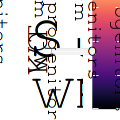

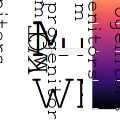

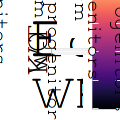

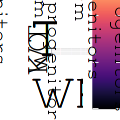

In [50]:
options(repr.plot.width=1, repr.plot.height=1)
plots = list()
for(i in 1:length(genes)){
   plots[[i]] = suppressMessages(plot_gene(genes[i]))
    }
names(plots) = genes
options(repr.plot.width=10, repr.plot.height=8)


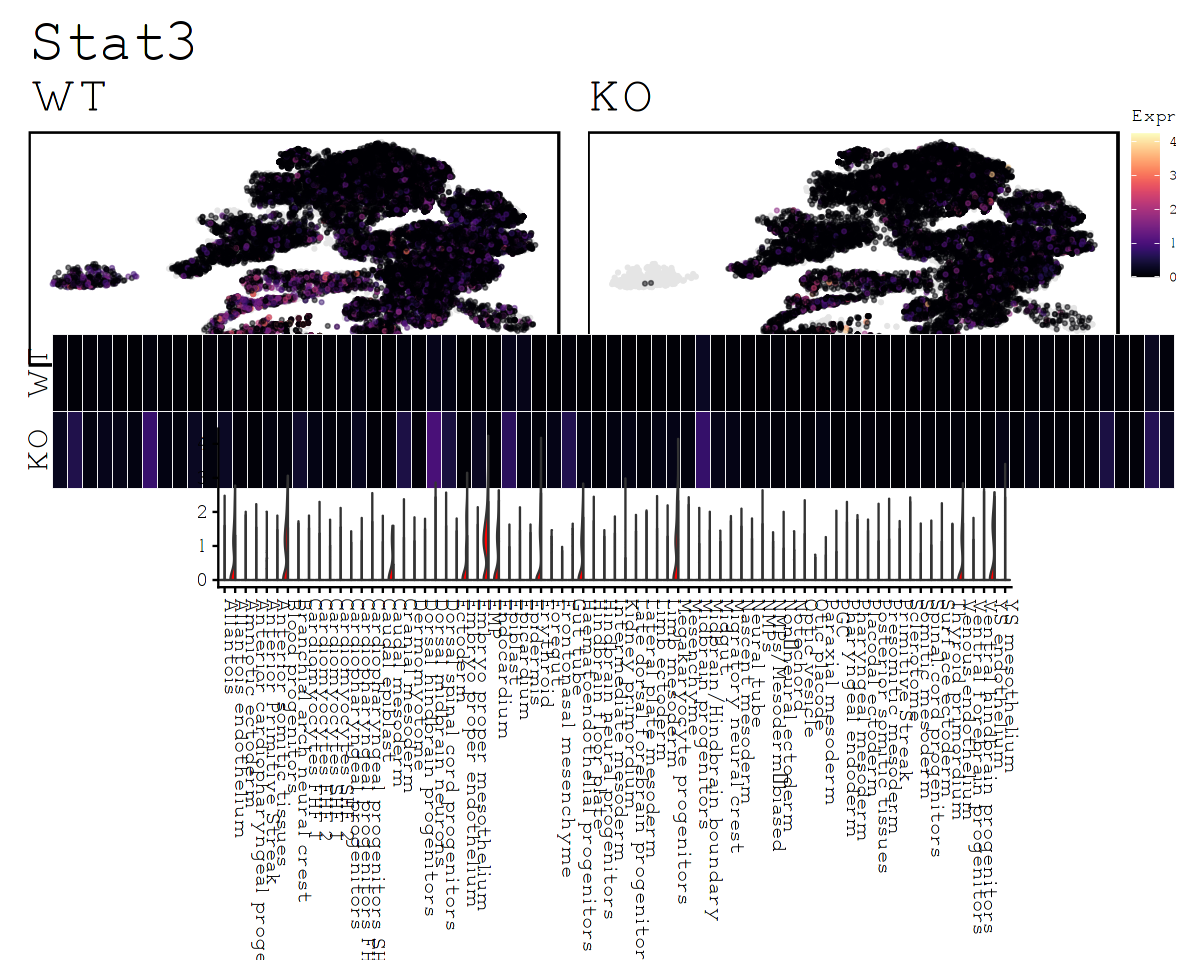

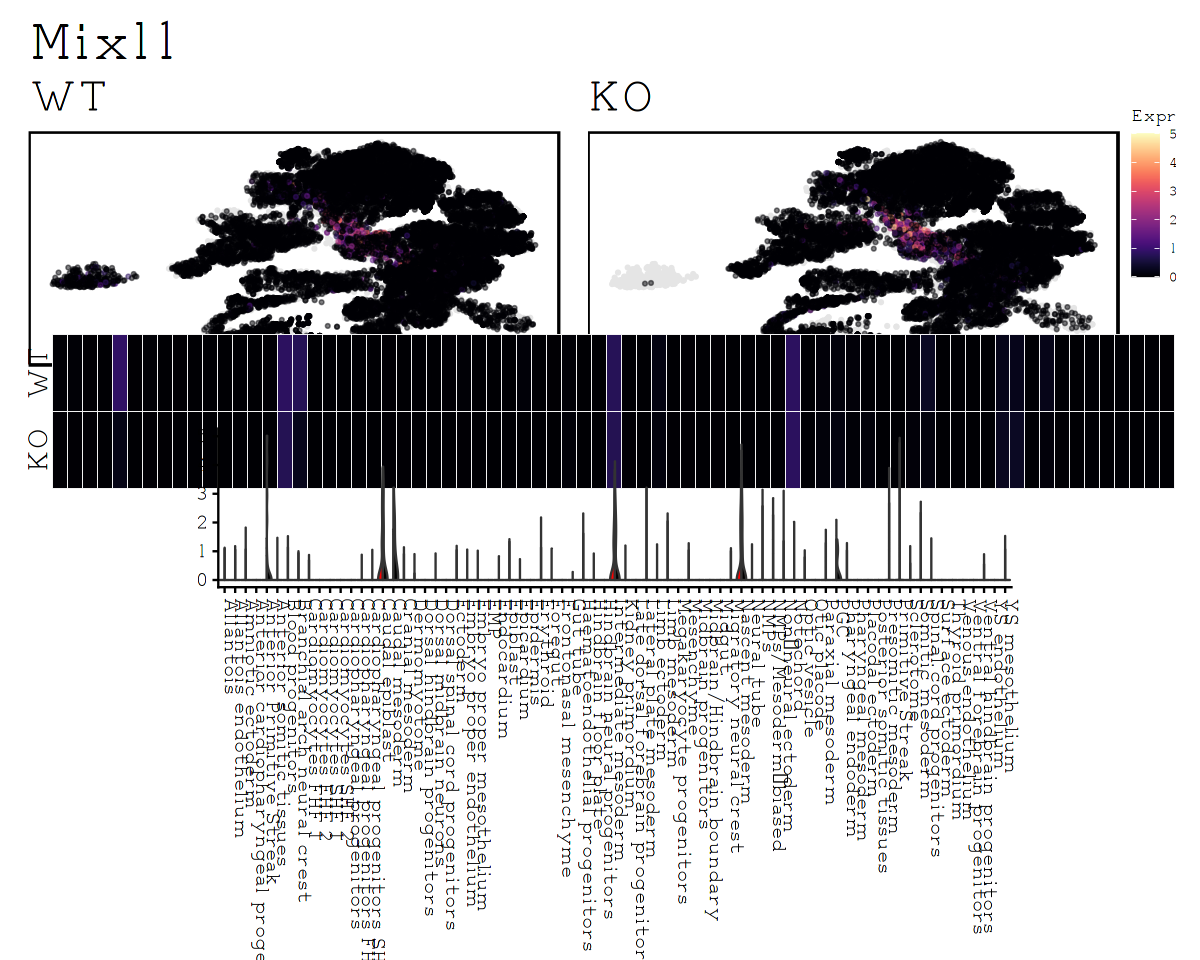

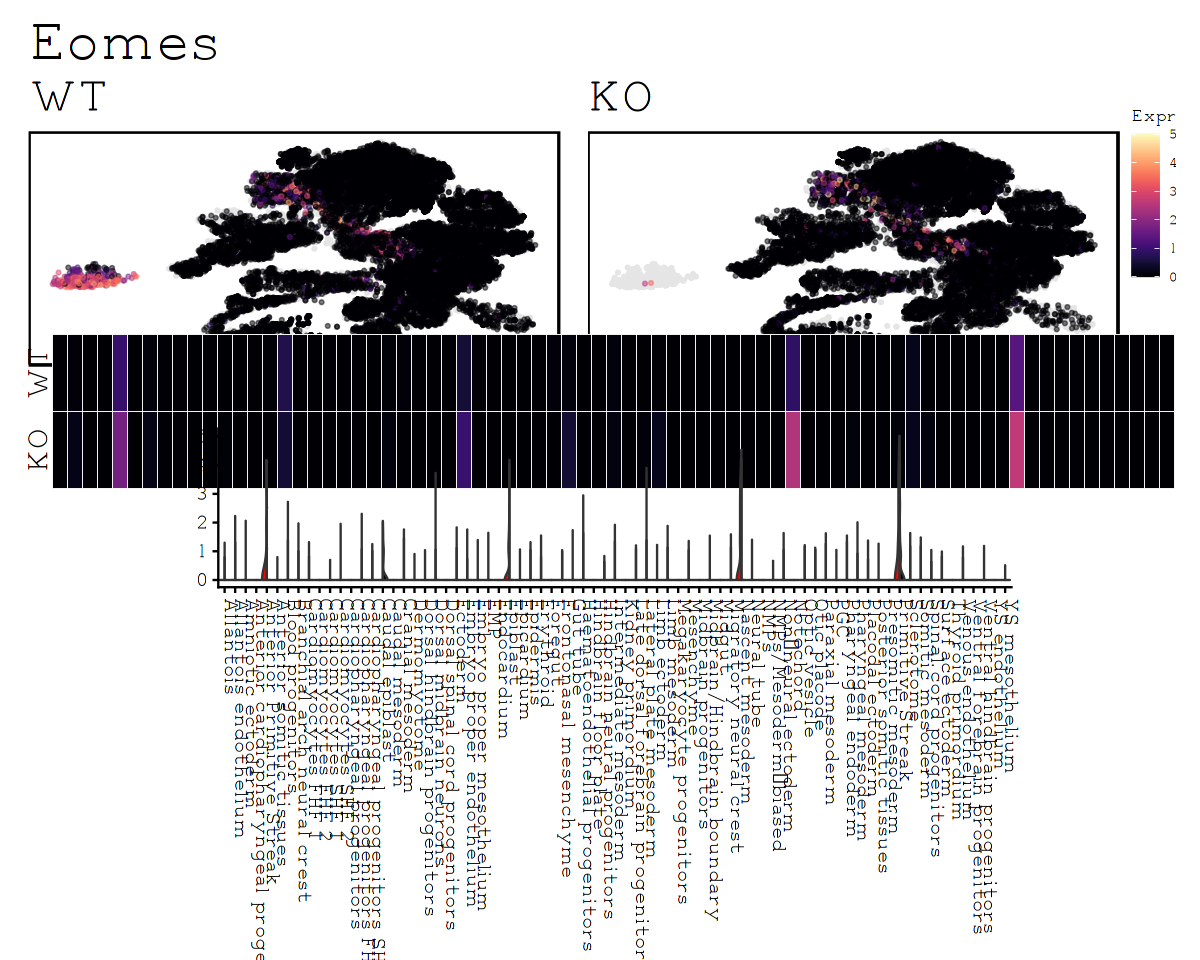

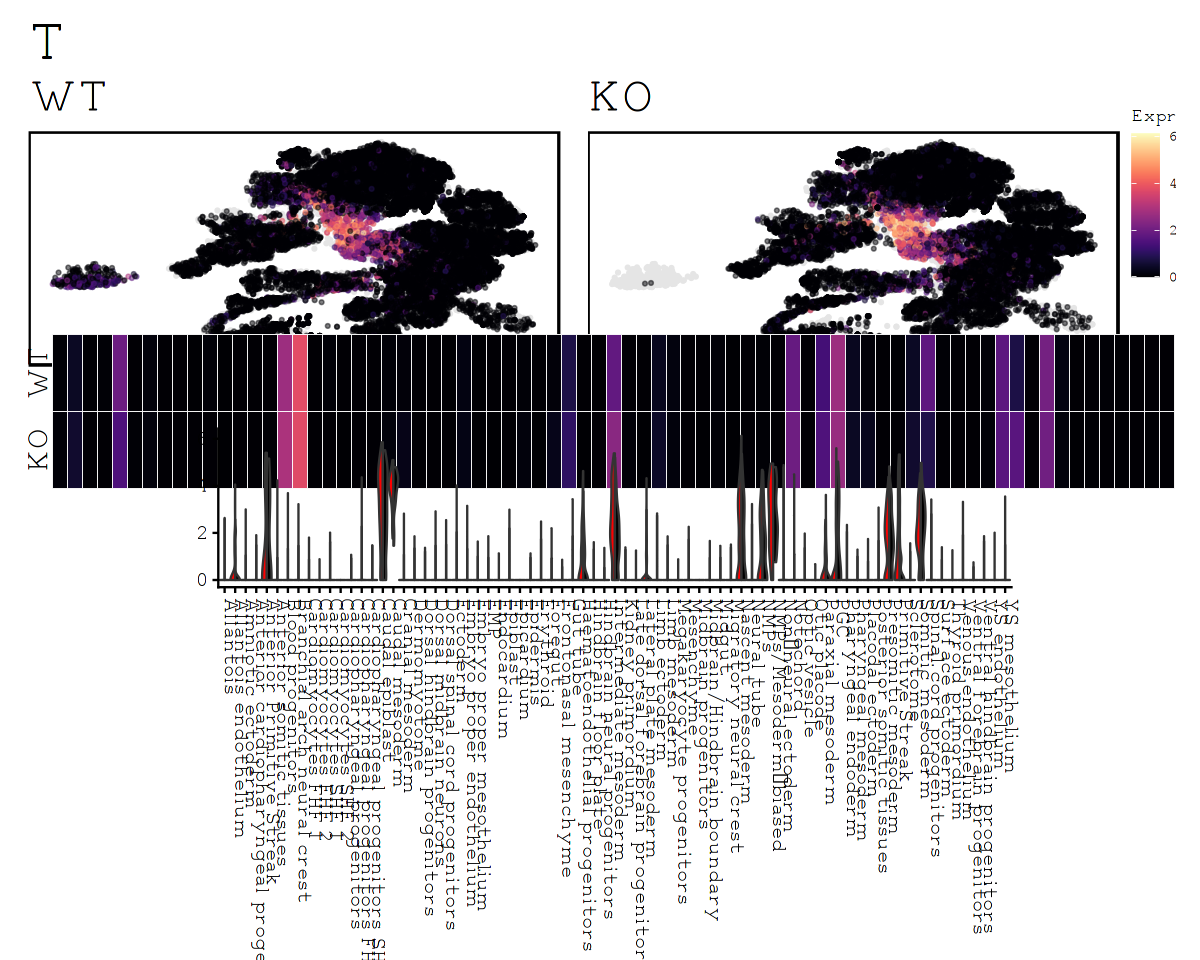

In [53]:
for(i in 1:length(plots)){
    suppressMessages(ggsave(paste0(plot_dir, 'gene_', names(plots[i]), '.png'), grid.arrange(plots[[i]]), device='png', width=10, height = 11))
}

### Plot gene scores

In [ ]:

plot_gene_score = function(x, name){
    score = Matrix::colMeans(logcounts(sce[x,]))/max(Matrix::colMeans(logcounts(sce[x,])))

    p1 = ggplot(WT, aes(umapX.mapped, umapY.mapped, col=as.vector(score[cell]))) + 
            geom_point(data=KO, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
            geom_point(size = 0.7, alpha = 0.5) + 
            scale_color_viridis(option='magma', begin=0, end = 0.5) + 
            labs(title = paste0(name, ' score'), 
                subtitle = 'WT') +
            umap_theme
    p2 = ggplot(KO, aes(umapX.mapped, umapY.mapped, col=as.vector(score[cell])))  + 
        geom_point(data=WT, aes(umapX.mapped, umapY.mapped), col='grey90', size = 0.7) + 
        geom_point(size = 0.7, alpha = 0.5) + 
        scale_color_viridis(option='magma') + 
        labs(title = paste0(''), 
             subtitle = 'KO') +
        umap_theme

df = data.frame('cell'=meta$cell, 'celltype' = meta$celltype.mapped, 'tdTom'= meta$tdTom, 'gene'= as.vector(Matrix::colMeans(logcounts(sce[x,]))))
df = df %>% group_by(celltype, tdTom) %>% summarize('mean' = mean(gene))#/max(gene))    

    p4 = ggplot(meta[meta$celltype.mapped %in% keep,], aes(celltype.mapped, tdTom, fill=as.vector(score)[meta$celltype.mapped %in% keep])) +       
        scale_fill_viridis(option='magma', name='') + 
        scale_y_discrete(labels=c('WT', 'KO'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 30, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 10, color='black'),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2)

        p3=ggplot(df[df$celltype %in% keep,], aes(celltype, tdTom, fill=mean)) +       
        scale_fill_viridis(option='magma', name='', end = max(df$mean)/max(as.vector(Matrix::colMeans(logcounts(sce[x,]))))) + 
        scale_y_discrete(labels=c('WT', 'KO'))+
        geom_tile(colour="white",size=0.2) +
        theme_void() +
        theme(axis.title.x=element_blank(),
              axis.title.y=element_blank(), 
              text= element_text(size = 20, color='black'), 
            #  axis.text.x=element_text(angle = -90, vjust = 0, hjust=0, size = 14, color='black'),
              axis.text.x=element_blank(),
              axis.text.y=element_text(angle=90), 
              legend.position='none',
              aspect.ratio = 0.2)
    
    grid.arrange(arrangeGrob(p1, p2, ncol=2), p3, p4, ncol=1)
}

In [195]:
Tgfs = c('Tgfbr1','Tgfbr2','Tgfbr3')
Bmps = c('Bmp1', 'Bmp2', 'Bmp3', 'Bmp4', 'Bmp5', 'Bmp6', 'Bmp7')
Activins = c('Acvr1', 'Acvr1b', 'Acvr1c')
Smad159 = c('Smad1', 'Smad5', 'Smad9')
Smad23 = c('Smad2', 'Smad3')

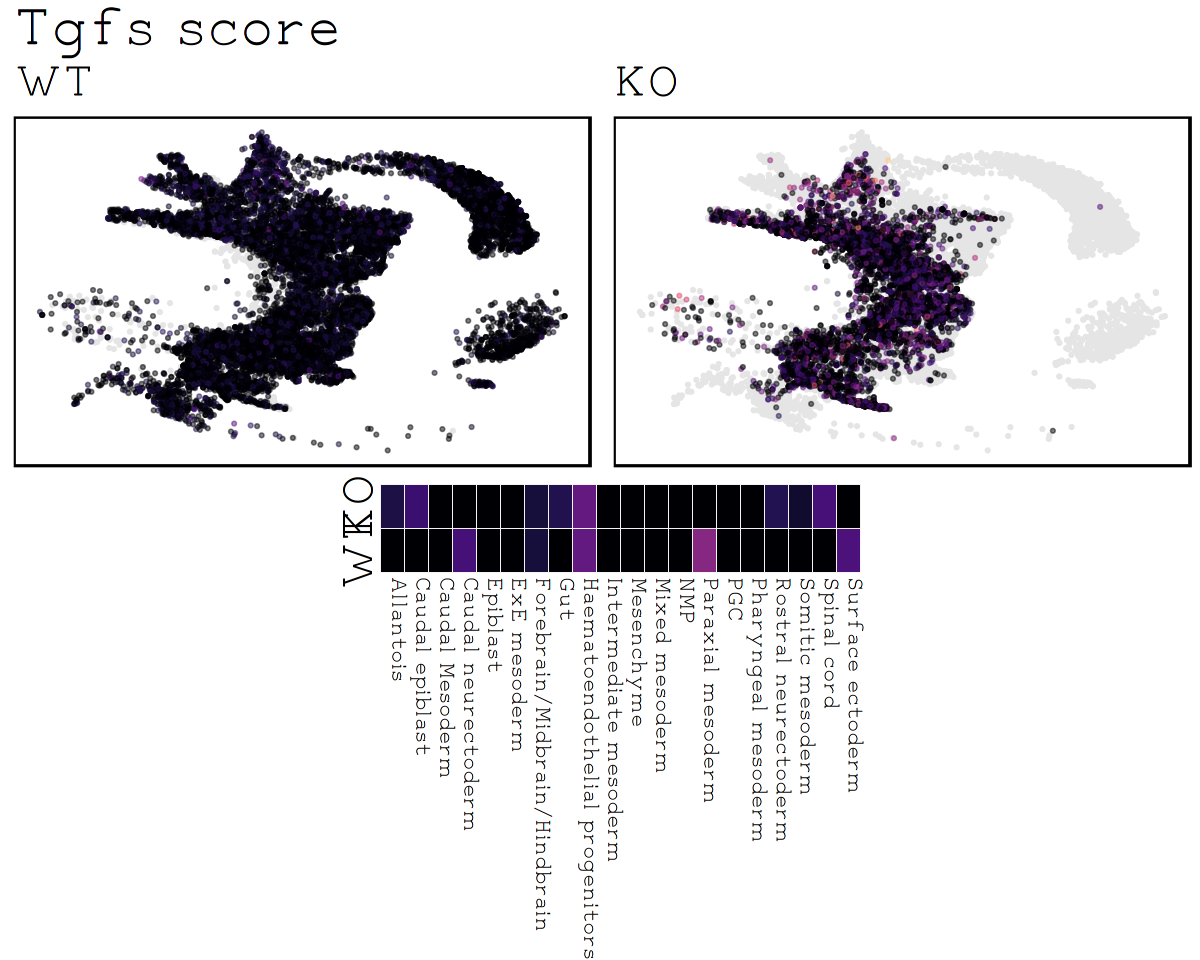

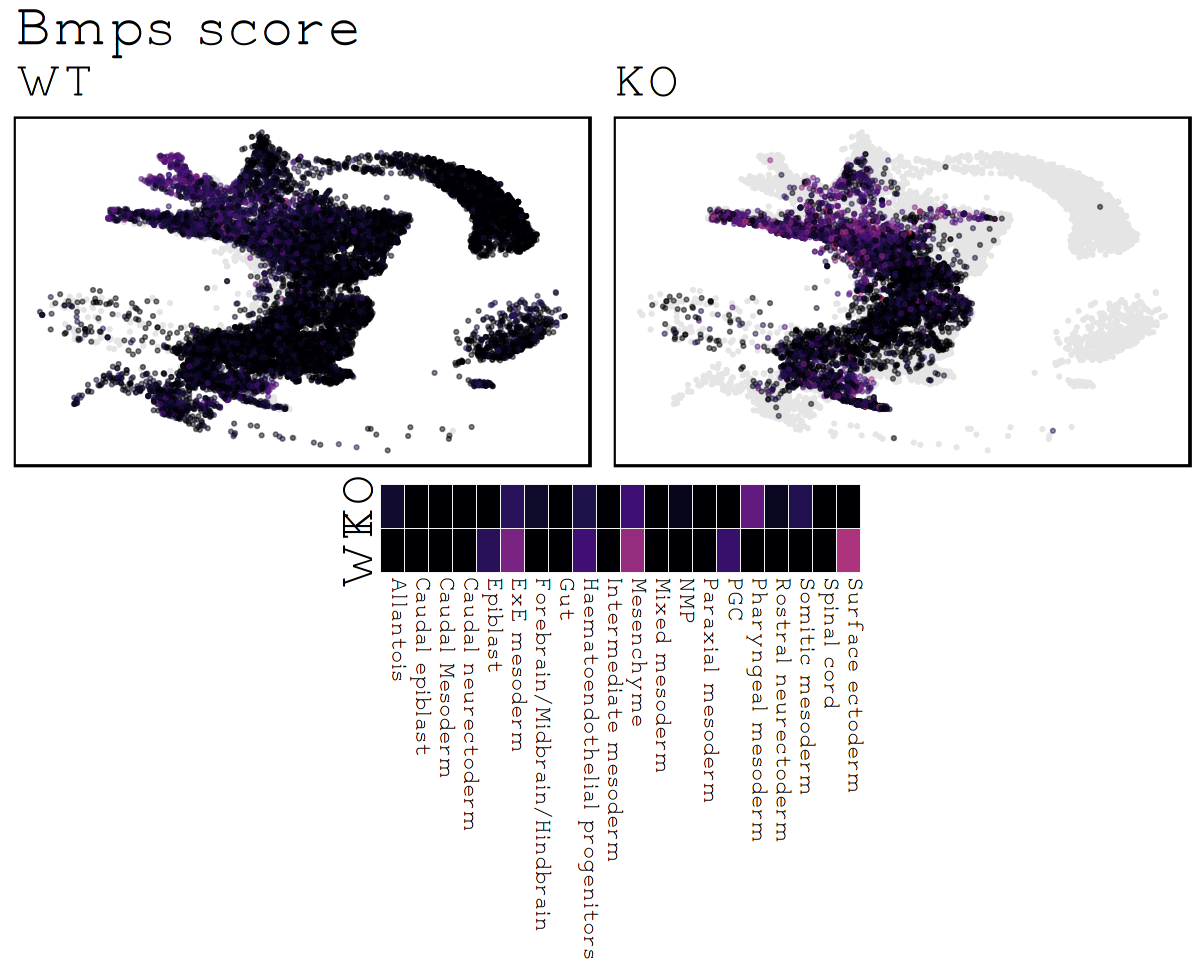

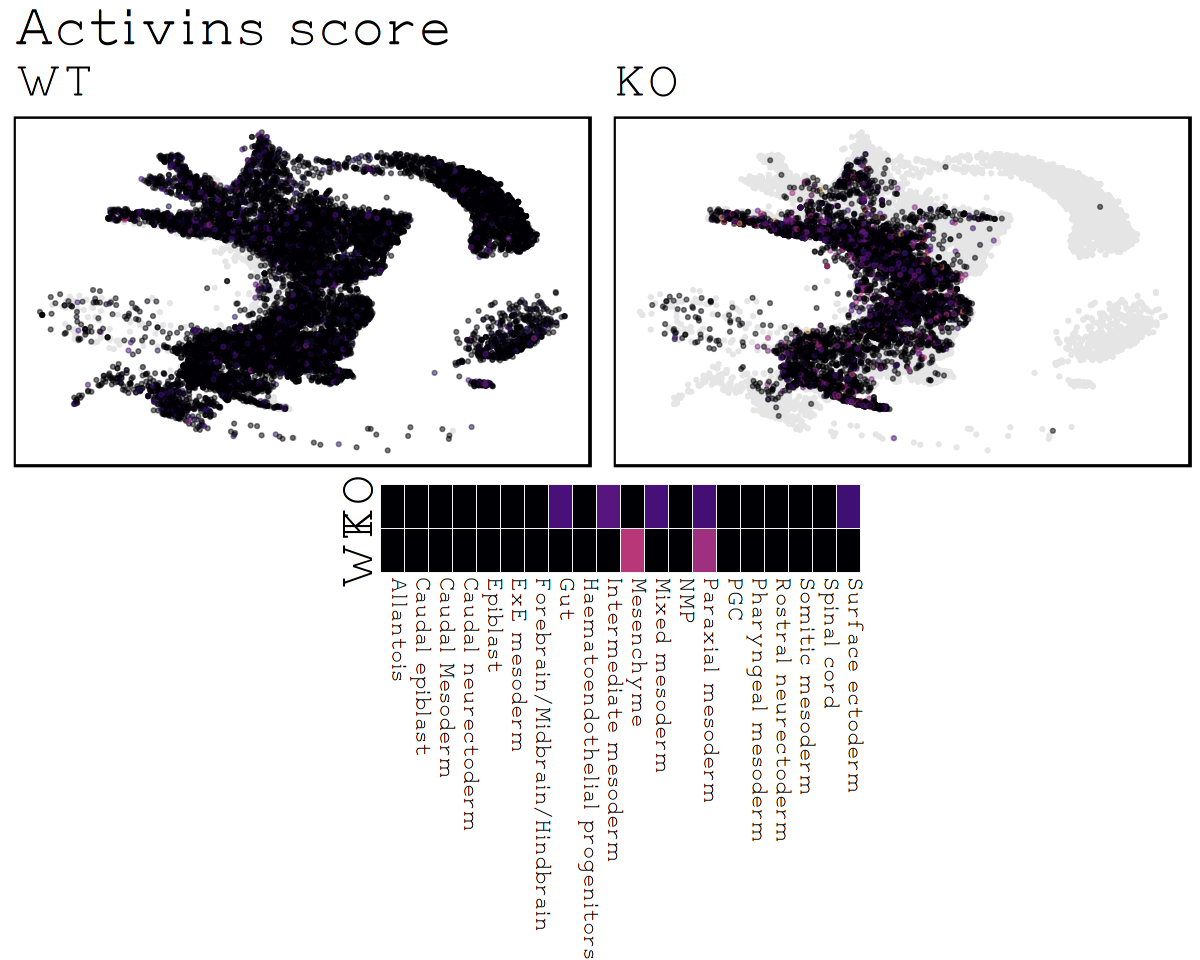

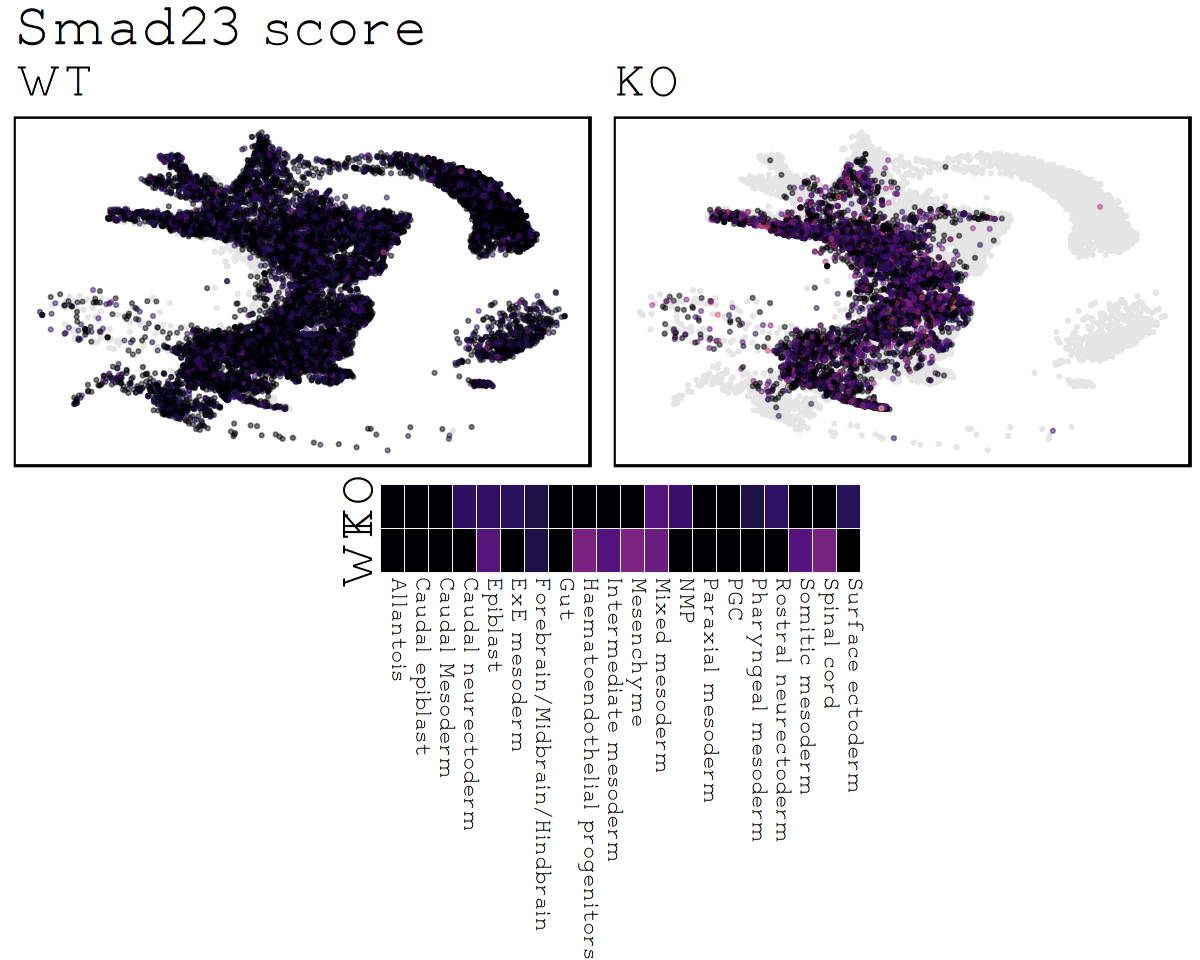

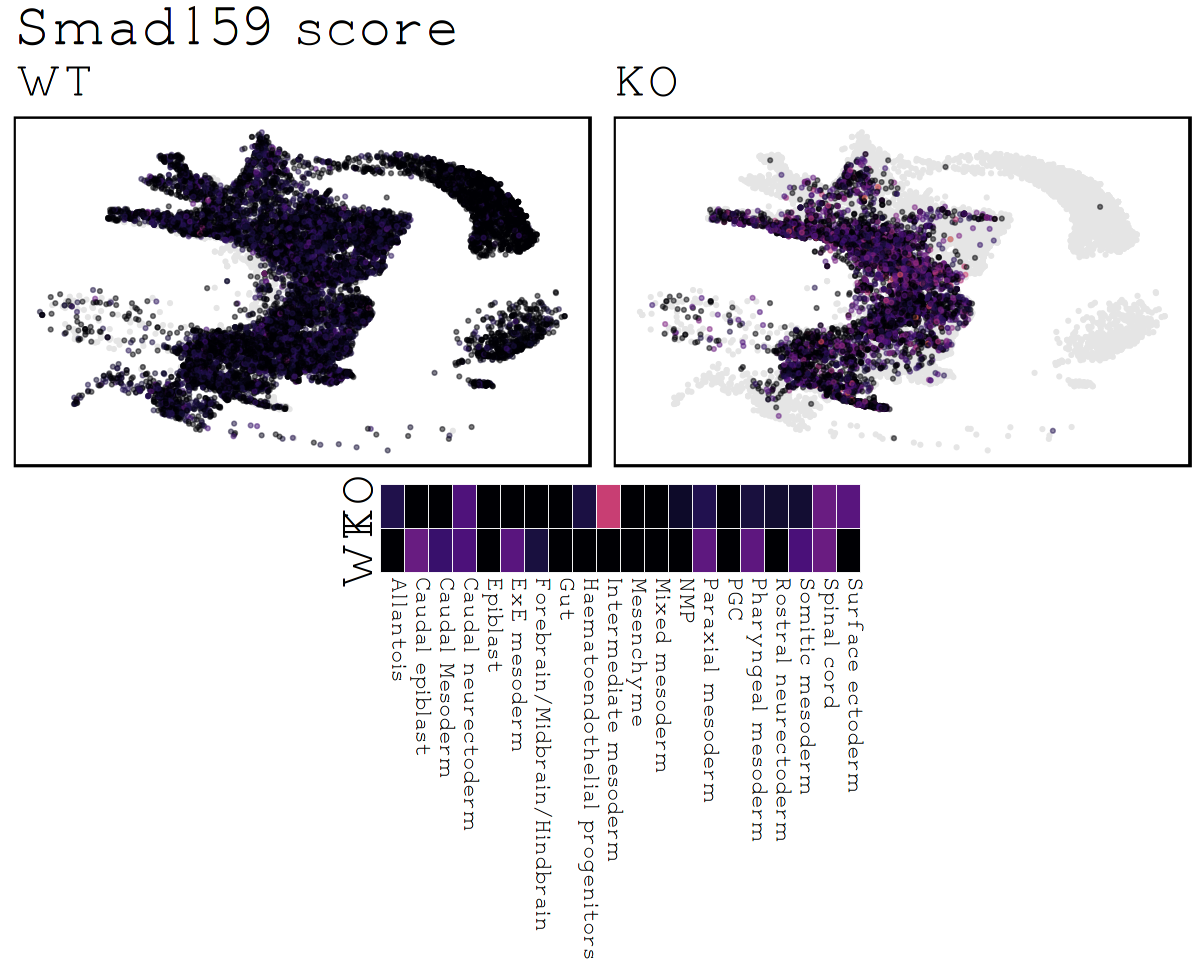

In [126]:
name = 'Tgfs'
plot = plot_gene_score(Tgfs, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Bmps'
plot = plot_gene_score(Bmps, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Activins'
plot = plot_gene_score(Activins, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Smad23'
plot = plot_gene_score(Smad23, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)
name = 'Smad159'
plot = plot_gene_score(Smad159, name)
ggsave(paste0(plot_dir, 'gene_score_', name, '.png'), plot, device='png', width=8, height = 9)

### EdgeR DEG analysis

In [21]:
opts = list()
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

# Function to differential expression
# - sce: SingleCellExperiment object with the column "group" in the colData
# - groups: the names of the two groups
# - min_detection_rate_per_group: minimum detection rate per group
doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.50) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(logcounts(sce[,sce$group==groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(logcounts(sce[,sce$group==groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  
  sce_edger <- scran::convertTo(sce, type="edgeR")
 # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    
  # Define design matrix (with intercept)
  cdr <- colMeans(logcounts(sce)>0)
  design <- model.matrix(~cdr+sce$group)
  
  # Estimate dispersions
  sce_edger  <- estimateDisp(sce_edger,design)
  
  # Fit GLM
  fit <- glmQLFit(sce_edger,design)
  
  # Likelihood ratio test
  lrt <- glmQLFTest(fit)
  
  # Construct output data.frame
  out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
    setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
    .[,c("logCPM","LR"):=NULL]
  
  return(out)
}

################
## Plot utils ##
################


gg_volcano_plot <- function(to.plot, top_genes=10, xlim=NULL, ylim=NULL, label_groups = NULL) {
  
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)]
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=105), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-6,6)) +
    scale_y_continuous(limits=c(0,115)) +
    annotate("text", x=0, y=115, size=4, label=sprintf("(%d)", all)) +
    annotate("text", x=-5, y=115, size=4, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=5, y=115, size=4, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=head(to.plot[sig==T],n=top_genes), aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=4) +
    theme_classic() +
    theme(
      axis.text = element_text(size=rel(0.75), color='black'),
      axis.title = element_text(size=rel(1.0), color='black'),
      legend.position="none"
    )
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

#### DEG between Tom+ and Tom- per celltype

In [22]:
sce$group = meta$tdTom
degs = lapply(unique(meta$celltype.mapped), function(x){     #unique(meta$celltype.mapped)
        sce_deg = sce[, meta$celltype.mapped==x]
        opts$groups = c('negative', 'positive')
        sce_deg$group = factor(sce_deg$group, levels = opts$groups)
        message(x)
        if(length(sce_deg$group[sce_deg$group == opts$groups[1]]) > 1 &    # Only select celltypes with 2 or more cells per group
            length(sce_deg$group[sce_deg$group == opts$groups[2]]) > 1){
            cdr.dt <- data.table(
              rownames(sce_deg),
              rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
              rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
            ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

            out <- doDiffExpr(sce_deg, opts$groups) %>%
              # Add sample statistics
              .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
              .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
              # Add gene statistics
            #  merge(cdr.dt, all.y=T, by="gene") %>%
              # Calculate statistical significance
              .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
              .[is.na(sig),sig:=FALSE] %>% 
              setorder(-sig, padj_fdr, na.last=T)

            # Parse columns
            out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
            }
        })

Erythroid

Mesenchyme

Anterior somitic tissues

Dorsal spinal cord progenitors

Spinal cord progenitors

Branchial arch neural crest

Amniotic ectoderm

Sclerotome

Hindbrain floor plate

Optic vesicle

YS endothelium

Ventral hindbrain progenitors

Cardiopharyngeal progenitors SHF

Cranial mesoderm

Thyroid primordium

Lateral plate mesoderm

Midbrain/Hindbrain boundary

Kidney primordium

Allantois

YS mesothelium

Migratory neural crest

Blood progenitors

Intermediate mesoderm

Cardiopharyngeal progenitors FHF

NMPs

Frontonasal mesenchyme

Limb ectoderm

PGC

Posterior somitic tissues

Epicardium

Hindbrain neural progenitors

EMP

Dermomyotome

Ectoderm

Allantois endothelium

Pharyngeal endoderm

Placodal ectoderm

Presomitic mesoderm

Embryo proper mesothelium

Non-neural ectoderm

Epidermis

Limb mesoderm

Ventral forebrain progenitors

Surface ectoderm

Megakaryocyte progenitors

Foregut

Dorsal hindbrain progenitors

Dorsal midbrain neurons

Caudal mesoderm

Pharyngeal meso

In [23]:
tomato_DEGs = rbindlist(degs)
write.csv(tomato_DEGs, paste0(out_dir, 'tomato_DEGs_edgeR_nonfiltered.csv'), row.names=FALSE)

In [24]:
plots = list()
for(i in 1:length(unique(tomato_DEGs$celltype))){
    plots[[i]] = gg_volcano_plot(tomato_DEGs[tomato_DEGs$celltype == unique(tomato_DEGs$celltype)[i],], top_genes = 25) + 
            labs(title = unique(tomato_DEGs$celltype)[i],
                 subtitle = paste0('n tdTom-: ', unique(tomato_DEGs$groupA_N)[i], ', n tdTom+: ', unique(tomato_DEGs$groupB_N)[i]))
}
names(plots) = gsub(" ", "_", unique(tomato_DEGs$celltype))
names(plots) = gsub("/", "_", unique(names(plots)))

pdf(sprintf('%sDEGs_across_celltypes_edgeR_nonfiltered.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 192 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 2 rows containing missing values (geom_text_repel).”


$Erythroid

$Mesenchyme

$Anterior_somitic_tissues

$Dorsal_spinal_cord_progenitors

$Spinal_cord_progenitors

$Branchial_arch_neural_crest

$Amniotic_ectoderm

$Sclerotome

$Hindbrain_floor_plate

$Optic_vesicle

$YS_endothelium

$Ventral_hindbrain_progenitors

$Cardiopharyngeal_progenitors_SHF

$Cranial_mesoderm

$Thyroid_primordium

$Lateral_plate_mesoderm

$Midbrain_Hindbrain_boundary

$Kidney_primordium

$Allantois

$YS_mesothelium

$Migratory_neural_crest

$Blood_progenitors

$Intermediate_mesoderm

$Cardiopharyngeal_progenitors_FHF

$NMPs

$Frontonasal_mesenchyme

$Limb_ectoderm

$PGC

$Posterior_somitic_tissues

$Epicardium

$Hindbrain_neural_progenitors

$EMP

$Dermomyotome

$Ectoderm

$Allantois_endothelium

$Pharyngeal_endoderm

$Placodal_ectoderm

$Presomitic_mesoderm

$Embryo_proper_mesothelium

$`Non-neural_ectoderm`

$Epidermis

$Limb_mesoderm

$Ventral_forebrain_progenitors

$Surface_ectoderm

$Megakaryocyte_progenitors

$Foregut

$Dorsal_hindbrain_progenitors

$Dorsal_

png 
  2

In [25]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/old/tomato_DEGs_edgeR.csv')

tomato_DEGs = tomato_DEGs[!tomato_DEGs$gene %in% exl_names & !tomato_DEGs$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]
write.csv(tomato_DEGs, paste0(out_dir, 'tomato_DEGs_edgeR_filtered.csv'), row.names=FALSE)

In [26]:
plots = list()
for(i in 1:length(unique(tomato_DEGs$celltype))){
    plots[[i]] = gg_volcano_plot(tomato_DEGs[tomato_DEGs$celltype == unique(tomato_DEGs$celltype)[i],], top_genes = 25) + 
            labs(title = unique(tomato_DEGs$celltype)[i],
                 subtitle = paste0('n tdTom-: ', unique(tomato_DEGs$groupA_N)[i], ', n tdTom+: ', unique(tomato_DEGs$groupB_N)[i]))
}
names(plots) = gsub(" ", "_", unique(tomato_DEGs$celltype))
names(plots) = gsub("/", "_", unique(names(plots)))

pdf(sprintf('%sDEGs_across_celltypes_edgeR_filtered.pdf', plot_dir))
    plots
dev.off()

Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 192 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”


$Erythroid

$Mesenchyme

$Anterior_somitic_tissues

$Dorsal_spinal_cord_progenitors

$Spinal_cord_progenitors

$Branchial_arch_neural_crest

$Amniotic_ectoderm

$Sclerotome

$Hindbrain_floor_plate

$Optic_vesicle

$YS_endothelium

$Ventral_hindbrain_progenitors

$Cardiopharyngeal_progenitors_SHF

$Cranial_mesoderm

$Thyroid_primordium

$Lateral_plate_mesoderm

$Midbrain_Hindbrain_boundary

$Kidney_primordium

$Allantois

$YS_mesothelium

$Migratory_neural_crest

$Blood_progenitors

$Intermediate_mesoderm

$Cardiopharyngeal_progenitors_FHF

$NMPs

$Frontonasal_mesenchyme

$Limb_ectoderm

$PGC

$Posterior_somitic_tissues

$Epicardium

$Hindbrain_neural_progenitors

$EMP

$Dermomyotome

$Ectoderm

$Allantois_endothelium

$Pharyngeal_endoderm

$Placodal_ectoderm

$Presomitic_mesoderm

$Embryo_proper_mesothelium

$`Non-neural_ectoderm`

$Epidermis

$Limb_mesoderm

$Ventral_forebrain_progenitors

$Surface_ectoderm

$Megakaryocyte_progenitors

$Foregut

$Dorsal_hindbrain_progenitors

$Dorsal_

png 
  2

#### DEG between Tom+ and Tom- all celltype

In [54]:
# DEG between Tom+ and Tom- all celltype
sce$group = meta$tdTom
sce_deg = sce
opts$groups = c('negative', 'positive')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)

    cdr.dt <- data.table(
      rownames(sce_deg),
      rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
      rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
    ) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

    out <- doDiffExpr(sce_deg, opts$groups) %>%
      # Add sample statistics
      .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
      .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
      # Add gene statistics
    #  merge(cdr.dt, all.y=T, by="gene") %>%
      # Calculate statistical significance
      .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
      .[is.na(sig),sig:=FALSE] %>% 
      setorder(-sig, padj_fdr, na.last=T)

    # Parse columns
    out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


In [55]:
tomato_DEGs = out
write.csv(tomato_DEGs, paste0(out_dir, 'tomato_DEGs_edgeR_all_nonfiltered.csv'), row.names=FALSE)

In [56]:
plots = list()
    plots =  gg_volcano_plot(tomato_DEGs, top_genes = 25) + 
            labs(title = 'All celltypes',
                 subtitle = paste0('n tdTom-: ', unique(tomato_DEGs$groupA_N), ', n tdTom+: ', unique(tomato_DEGs$groupB_N)))


pdf(sprintf('%sDEGs_all_celltypes_edgeR_nonfiltered.pdf', plot_dir))
    plots
dev.off()

png 
  2

In [57]:
#exclude genes
xist = "ENSMUSG00000086503"
ychr = read.table("/rds/project/rds-SDzz0CATGms/users/bt392/software/ygenes.tab", stringsAsFactors = FALSE)[,1]
other = c("tomato-td") #for the chimera

exl_names = genenames[genenames$gene %in% c(ychr, xist, other)]$gene_name

WT_inj = read.csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/tomato_DEGs_edgeR.csv')

out = out[!out$gene %in% exl_names & !out$gene %in% WT_inj[WT_inj$sig==TRUE, 1]]
write.csv(out, paste0(out_dir, 'tomato_DEGs_all_celltypes_edgeR_filtered.csv'), row.names=FALSE)

In [58]:
plot = gg_volcano_plot(out, top_genes = 35) + 
            labs(title = 'DEGs all celltypes',
                 subtitle = paste0('n tdTom-: ', unique(out$groupA_N), 
                                   ', n tdTom+: ', unique(out$groupB_N)))

pdf(sprintf('%sDEGs_all_celltypes_edgeR_filtered.pdf', plot_dir))
    plot
dev.off()

png 
  2

### Plot DEGs

In [ ]:
genes = read.csv(paste0(out_dir, 'tomato_DEGs_all_celltypes_edgeR_filtered.csv'))